# Dissecting a Real Vision-Language Model
## LLaVA architecture — SigLIP + MLP projector + Qwen2

In the previous notebooks we built a ViT from scratch and understood how it turns images into token sequences.  We then used CLIP to understand how to project images and text into the same embedding space.
Now we go one step further: **how do you combine vision and language into a single model?**

Rather than building a toy, we will **load a real, small VLM and carefully open it up** and try to understand how it works.


---

### Our subject: LLaVA-Interleave-Qwen-0.5B

This model is a minimal but fully functional VLM following the **LLaVA architecture**, one of the most cited VLM designs in the literature.  
It has three components:

```
┌────────────────────────────────────────────────────────────────────┐
│                  LLaVA-Interleave-Qwen-0.5B                        │
│                                                                    │
│  ┌──────────────────┐   ┌──────────────────┐   ┌───────────────┐   │
│  │   Vision Tower   │──►│  MM Projector    │──►│ Language Model│   │
│  │  (SigLIP ViT)    │   │  (MLP, 2 layers) │   │  (Qwen2-0.5B) │   │
│  │                  │   │                  │   │               │   │
│  │  Image → patches │   │ D_vis → D_text   │   │ Text decoder  │   │
│  └──────────────────┘   └──────────────────┘   └───────────────┘   │
│                                                                    │
│   ~400M params            ~2M params              ~464M params     │
└────────────────────────────────────────────────────────────────────┘
```

Notice: the vision encoder is **comparable in size** to the language model here. This is unusual, modern VLM architectures rely on a **large language model** to do the heavy lifting.

---
## 1 — Setup & Load the Model

In [68]:
#!pip install -q transformers accelerate Pillow requests

In [69]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
from PIL import Image
from io import BytesIO
from transformers import AutoProcessor, LlavaForConditionalGeneration

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [70]:
MODEL_ID = 'llava-hf/llava-interleave-qwen-0.5b-hf'

processor = AutoProcessor.from_pretrained(MODEL_ID)
model     = LlavaForConditionalGeneration.from_pretrained(
                MODEL_ID, torch_dtype=torch.float32
            )
model     = model.to(device).eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'\nModel loaded — {total_params/1e6:.0f}M parameters total')

Loading weights: 100%|██████████| 715/715 [00:00<00:00, 1255.78it/s, Materializing param=model.vision_tower.vision_model.post_layernorm.weight]                      



Model loaded — 864M parameters total


**864M parameters** — that's smaller than most LLMs but still a fully functional VLM. For reference, GPT-2 was 1.5B and LLaMA-7B is 8× larger. The small size makes this model perfect for dissection: large enough to produce real outputs, small enough to load on a single GPU and inspect every layer.

---
## 2 — Reading the Architecture

The first thing to do with any new model: **print it and read the tree**.

HuggingFace models have a `repr` that shows every submodule. Let's use it to identify the three main blocks and understand how many parameters each one contributes.

In [71]:
print('=== Top-level submodules ===')
for name, module in model.named_children():
    param_count = sum(p.numel() for p in module.parameters())
    print(f'  {name:<30} {type(module).__name__:<40} {param_count/1e6:>7.1f}M params')

=== Top-level submodules ===
  model                          LlavaModel                                 864.0M params
  lm_head                        Linear                                     155.6M params


Notice that the top-level shows just two children: `model` (the `LlavaModel` containing all three blocks) and `lm_head` (the final linear layer that maps hidden states to vocabulary logits). The `lm_head` has 155.6M params because it maps from D_text=1024 to a vocabulary of 152k tokens — and its weights are **tied** with the embedding table inside the language model (same tensor, counted twice).

In [72]:
# Print the full model tree — dense, but worth scanning.
# Look for: vision_tower, multi_modal_projector, language_model
print(model)

LlavaForConditionalGeneration(
  (model): LlavaModel(
    (vision_tower): SiglipVisionModel(
      (vision_model): SiglipVisionTransformer(
        (embeddings): SiglipVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
          (position_embedding): Embedding(729, 1152)
        )
        (encoder): SiglipEncoder(
          (layers): ModuleList(
            (0-25): 26 x SiglipEncoderLayer(
              (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
              (self_attn): SiglipAttention(
                (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
                (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
                (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
                (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
              )
              (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_

**How to read this architecture tree:**

Scan for the three main blocks nested inside `model`:

1. **`vision_tower`** (SiglipVisionModel) — A standard ViT: `Conv2d` for patch embedding, positional `Embedding`, then 26 `SiglipEncoderLayer` blocks each with self-attention and an MLP. Note the hidden dimension of **1152** throughout.

2. **`multi_modal_projector`** — Just two `Linear` layers with a `GELU` activation in between. This is the entire bridge between vision and language.

3. **`language_model`** (Qwen2Model) — A causal Transformer decoder: token `Embedding`, 24 `Qwen2DecoderLayer` blocks with self-attention and a gated MLP (SwiGLU), plus `RMSNorm` and `RotaryEmbedding` (RoPE). Hidden dimension is **1024**.

The architectural mismatch (1152 vs 1024) is exactly why the projector exists.

---
## 3 — A Word on the Processor

Before diving into the model, let's briefly understand the **processor** — the preprocessing layer that sits *before* the neural network.

The processor is not part of the model. It is a pure data preparation utility that wraps two independent components:

```
                     ┌──────────────────────────────────────────┐
                     │                Processor                 │
                     │                                          │
 Raw image (PIL) ───►│  SiglipImageProcessor                    │───► pixel_values  (B, C, H, W)
                     │    • resize to 384×384                   │
                     │    • normalise with SigLIP mean/std      │
                     │                                          │
 Raw text (str)  ───►│  Qwen2Tokenizer                          │───► input_ids     (B, T)
                     │    • split text into subword tokens      │───► attention_mask (B, T)
                     │    • map tokens to integer IDs           │
                     │    • expand <image> into N placeholders  │
                     └──────────────────────────────────────────┘
```

**SiglipImageProcessor** knows the exact resolution and normalisation statistics that SigLIP was trained with (mean and std per channel). Feeding an image with wrong normalisation would silently degrade performance.

**Qwen2Tokenizer** uses a BPE vocabulary of 150k+ tokens. Importantly, it expands a single `<image>` tag in the prompt into **N repeated `<image>` placeholder tokens** — one per visual token that will be injected. This is the "seam" between the two modalities.

In [73]:
print('Processor type:', type(processor).__name__)
print()
print('Image processor:', type(processor.image_processor).__name__)
print(f'  Expected image size : {processor.image_processor.size}')
print(f'  Normalisation mean  : {processor.image_processor.image_mean}')
print(f'  Normalisation std   : {processor.image_processor.image_std}')
print()
print('Tokenizer:', type(processor.tokenizer).__name__)
print(f'  Vocabulary size : {processor.tokenizer.vocab_size:,} tokens')
print(f'  Image token     : {repr(processor.tokenizer.decode([model.config.image_token_index]))}')

Processor type: LlavaProcessor

Image processor: SiglipImageProcessorFast
  Expected image size : {'height': 384, 'width': 384}
  Normalisation mean  : [0.5, 0.5, 0.5]
  Normalisation std   : [0.5, 0.5, 0.5]

Tokenizer: TokenizersBackend
  Vocabulary size : 151,643 tokens
  Image token     : '<image>'


---
## 4 — Preparing our Inputs

Before feeding anything to the model, we need to preprocess our raw data. The processor handles both modalities: it resizes and normalises the image for SigLIP, and tokenizes the text prompt for Qwen2 — including the crucial step of expanding `<image>` into the right number of placeholder tokens.

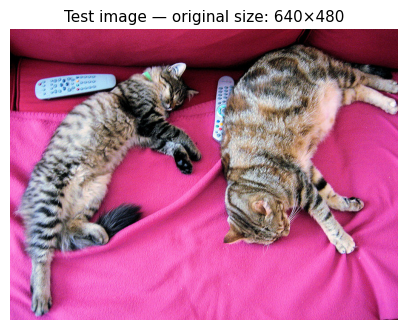

In [74]:
# Load a test image
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'  # two cats on a couch
response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert('RGB')

plt.figure(figsize=(5, 4))
plt.imshow(image)
plt.title(f'Test image — original size: {image.size[0]}×{image.size[1]}', fontsize=11)
plt.axis('off')
plt.show()

In [75]:
# LLaVA-style prompt: <image> token placed before the question
prompt = '<image>\nWhat do you see in this image?'

inputs = processor(
    text=prompt,
    images=image,
    return_tensors='pt'
).to(device)

print('Outputs of the processor:')
for k, v in inputs.items():
    print(f'  {k:<25} shape: {tuple(v.shape)}  dtype: {v.dtype}')

Outputs of the processor:
  input_ids                 shape: (1, 738)  dtype: torch.int64
  attention_mask            shape: (1, 738)  dtype: torch.int64
  pixel_values              shape: (1, 3, 384, 384)  dtype: torch.float32


**Interpreting the shapes:**

- **`pixel_values` (1, 3, 384, 384)** — The image resized to SigLIP's expected 384×384 resolution, with 3 colour channels, pixel values normalised to [-1, 1].
- **`input_ids` (1, 738)** — The tokenized prompt. But our text is only ~9 tokens long — so where do the other 729 come from? The processor expanded the single `<image>` tag into **729 placeholder tokens**, one per image patch (27×27 = 729). These placeholders will later be replaced by actual visual embeddings.
- **`attention_mask` (1, 738)** — All ones, meaning every token (both image placeholders and text) should be attended to.

---
## 5 — Block 1: The Vision Tower (SigLIP ViT)

The vision encoder is **SigLIP** (Sigmoid Loss for Language-Image Pre-training) — a variant of CLIP that uses a sigmoid-based contrastive loss instead of the softmax-based one in the original CLIP.  
It has **398M params**, uses a patch size of **14 pixels**, and expects an input resolution of **384×384**.

Its architecture is essentially what you built in the previous notebook: a Vision Transformer that turns an image into a sequence of patch embeddings. The key difference is *how it was trained*: not for classification, but to **align image embeddings with text embeddings** using contrastive learning — which is why it transfers so well to VLMs.

One important difference from the original CLIP ViT: **SigLIP has no CLS token**. All output tokens are patch tokens.

Let's pass the image through it in isolation.

In [76]:
# Access the SigLIP vision encoder
vision_tower = model.model.vision_tower

print('Vision tower type:', type(vision_tower).__name__)
clip_params = sum(p.numel() for p in vision_tower.parameters())
print(f'Parameters: {clip_params/1e6:.0f}M')
print()

# Inspect the SigLIP config
cfg = vision_tower.config
print('SigLIP vision config:')
print(f'  Input resolution : {cfg.image_size}×{cfg.image_size}')
print(f'  Patch size       : {cfg.patch_size}×{cfg.patch_size}')
print(f'  Number of patches: ({cfg.image_size}/{cfg.patch_size})² = {(cfg.image_size // cfg.patch_size)**2}')
print(f'  Hidden dim       : {cfg.hidden_size}   ← D_vis')
print(f'  Num layers       : {cfg.num_hidden_layers}')
print(f'  Num heads        : {cfg.num_attention_heads}')
print()
print('Note: SigLIP has NO CLS token — all output tokens are patch tokens.')

Vision tower type: SiglipVisionModel
Parameters: 398M

SigLIP vision config:
  Input resolution : 384×384
  Patch size       : 14×14
  Number of patches: (384/14)² = 729
  Hidden dim       : 1152   ← D_vis
  Num layers       : 26
  Num heads        : 16

Note: SigLIP has NO CLS token — all output tokens are patch tokens.


**Key numbers to remember:**
- **384 / 14 = 27** patches per side, so **27 × 27 = 729** total patches
- **D_vis = 1152** — the dimension of each patch embedding coming out of SigLIP
- **26 layers** — a deep encoder, which is why the vision tower alone accounts for ~400M of the 864M total params

Now let's actually run the image through SigLIP and see what comes out.

In [77]:
# pixel_values: (B, C, H, W)
pixel_values = inputs['pixel_values']
print(f'pixel_values shape : {tuple(pixel_values.shape)}')
print(f'  Resolution fed to SigLIP: {pixel_values.shape[2]}×{pixel_values.shape[3]}')
print(f'  (processor resized from {image.size[0]}×{image.size[1]} to {pixel_values.shape[2]}×{pixel_values.shape[3]})')
print()

# Forward pass through the vision tower only
with torch.no_grad():
    vision_outputs = vision_tower(pixel_values, output_hidden_states=True)

# Which hidden layer to extract features from is controlled by
# model.config.vision_feature_layer.
feature_layer = model.config.vision_feature_layer
patch_embeddings = vision_outputs.hidden_states[feature_layer]

# In Python, index -1 = last element, -2 = second-to-last, etc.
n_layers = len(vision_outputs.hidden_states) - 1  # subtract 1 for the initial embedding
layer_description = f'layer {n_layers + feature_layer} of {n_layers}' if feature_layer < 0 else f'layer {feature_layer} of {n_layers}'
print(f'Using hidden_states[{feature_layer}]  →  {layer_description}')
print(f'Patch embeddings shape    : {tuple(patch_embeddings.shape)}')
print()
print('Breakdown:')
print(f'  B          = {patch_embeddings.shape[0]}   (batch size)')
print(f'  N_patches  = {patch_embeddings.shape[1]}   ({cfg.image_size//cfg.patch_size}×{cfg.image_size//cfg.patch_size} = {(cfg.image_size // cfg.patch_size)**2} patches, no CLS token)')
print(f'  D_vis      = {patch_embeddings.shape[2]}')

pixel_values shape : (1, 3, 384, 384)
  Resolution fed to SigLIP: 384×384
  (processor resized from 640×480 to 384×384)

Using hidden_states[-1]  →  layer 25 of 26
Patch embeddings shape    : (1, 729, 1152)

Breakdown:
  B          = 1   (batch size)
  N_patches  = 729   (27×27 = 729 patches, no CLS token)
  D_vis      = 1152


**What just happened:** The raw image pixels (384×384×3) were transformed into a sequence of **729 vectors of dimension 1152**. Each vector is a rich, contextualised representation of one 14×14 patch — but after 26 layers of self-attention, each patch "knows about" the entire image, not just its local region.

We extract features from `hidden_states[-1]` (the last layer). Some LLaVA variants use the second-to-last layer instead, trading off final-layer abstraction for slightly more spatial detail.

**Why not just use the final output?** The model stores `output_hidden_states=True` to give us access to every intermediate layer. The config parameter `vision_feature_layer` controls which one gets passed to the projector.

In [78]:
# LLaVA's vision_feature_select_strategy controls whether a CLS token (if present) is kept or dropped.
# For SigLIP there is no CLS token, so "full" simply means: keep all patch tokens as-is.
strategy = model.config.vision_feature_select_strategy
print(f'vision_feature_select_strategy: "{strategy}"')
print()

if strategy == 'default':
    # For models WITH a CLS token (e.g. original CLIP): drop it, keep only patch tokens
    patch_embeddings_no_cls = patch_embeddings[:, 1:, :]
    print('Strategy "default": CLS token dropped, only patch tokens kept.')
else:
    # "full": keep everything — for SigLIP this is all patch tokens (no CLS to drop)
    patch_embeddings_no_cls = patch_embeddings
    print('Strategy "full": all tokens kept.')
    print('  (SigLIP has no CLS token, so this is just all 729 patch tokens.)')

print(f'\nPatch embeddings passed to projector: {tuple(patch_embeddings_no_cls.shape)}')

vision_feature_select_strategy: "full"

Strategy "full": all tokens kept.
  (SigLIP has no CLS token, so this is just all 729 patch tokens.)

Patch embeddings passed to projector: (1, 729, 1152)


**Status check:** We now have **729 patch embeddings** of dimension **1152** — the vision tower's job is done. But the language model expects dimension **1024**. The projector will bridge this gap next.

---
## 6 — Block 2: The Multi-Modal Projector (MLP Bridge)

This is **the core engineering idea of LLaVA** — and it is intentionally as simple as possible.

SigLIP outputs embeddings of dimension **D_vis = 1152**.  
The Qwen2 language model expects embeddings of dimension **D_text = 1024**.  
The dimensions don't match — so the projector must bridge them:

```
Patch embeddings from SigLIP      Projector MLP             LM input tokens
(B, N_patches, 1152)           ─────────────────►      (B, N_patches, 1024)
                                Linear(1152, 1024)
                                GELU
                                Linear(1024, 1024)
```

Even if dimensions happened to match, the two models were trained **completely independently** in different representation spaces — a learned mapping is still needed to align them.

In [79]:
projector = model.model.multi_modal_projector

print('Projector architecture:')
print(projector)
print()

proj_params = sum(p.numel() for p in projector.parameters())
print(f'Parameters: {proj_params/1e6:.2f}M')
print()

# Read the weight shapes directly
print('Layer-by-layer weight shapes:')
for name, param in projector.named_parameters():
    print(f'  {name:<40} {tuple(param.shape)}')

Projector architecture:
LlavaMultiModalProjector(
  (linear_1): Linear(in_features=1152, out_features=1024, bias=True)
  (act): GELUActivation()
  (linear_2): Linear(in_features=1024, out_features=1024, bias=True)
)

Parameters: 2.23M

Layer-by-layer weight shapes:
  linear_1.weight                          (1024, 1152)
  linear_1.bias                            (1024,)
  linear_2.weight                          (1024, 1024)
  linear_2.bias                            (1024,)


**Only 2.23M parameters** — the projector is by far the smallest component (0.26% of the total model). This is a deliberate design choice in LLaVA: keep the bridge minimal and let the pre-trained vision and language models do the heavy lifting. During LLaVA training, this tiny projector is the *only* component trained in the first stage (vision tower and LM are frozen), which makes the initial alignment phase very fast and data-efficient.

In [80]:
print('Input to projector  :', tuple(patch_embeddings_no_cls.shape))

with torch.no_grad():
    visual_tokens = projector(patch_embeddings_no_cls)

print('Output of projector :', tuple(visual_tokens.shape))
print()

D_vis  = patch_embeddings_no_cls.shape[-1]
D_text = visual_tokens.shape[-1]
N      = visual_tokens.shape[1]

print(f'  D_vis  →  D_text  :  {D_vis}  →  {D_text}')
print(f'  N_patches unchanged:  {N}  (no spatial pooling — every patch becomes one token)')
print()
print('  Unlike SmolVLM, LLaVA keeps ALL patch tokens.')
print(f'  The LM will receive {N} visual tokens — one per SigLIP patch.')

Input to projector  : (1, 729, 1152)
Output of projector : (1, 729, 1024)

  D_vis  →  D_text  :  1152  →  1024
  N_patches unchanged:  729  (no spatial pooling — every patch becomes one token)

  Unlike SmolVLM, LLaVA keeps ALL patch tokens.
  The LM will receive 729 visual tokens — one per SigLIP patch.


**Critical observation:** The number of tokens is **unchanged** — still 729. Unlike SmolVLM's pixel-shuffle connector that compresses 729 tokens down to ~81, LLaVA keeps every single patch token. This means the language model will process all 729 visual tokens, which is more expensive but preserves maximum spatial detail.

The only thing that changed is the embedding dimension: **1152 → 1024**, matching the LM's hidden size. Let's verify this by manually stepping through the two linear layers.

In [81]:
# Let's manually reproduce what the projector does — it's just two linear layers
# This is the fill-in-the-blank exercise:

# ── Reproduce the projector from scratch ─────────────────────────────────────
linear1 = projector.linear_1   # first Linear layer
act     = projector.act        # GELU activation
linear2 = projector.linear_2   # second Linear layer

with torch.no_grad():
    step1 = linear1(patch_embeddings_no_cls)
    print(f'After linear_1 : {tuple(step1.shape)}')
    step2 = act(step1)
    print(f'After GELU     : {tuple(step2.shape)}')
    step3 = linear2(step2)
    print(f'After linear_2 : {tuple(step3.shape)}')

# Verify it matches the projector's own output
print()
match = torch.allclose(step3, visual_tokens, atol=1e-5)
print(f'Manual result matches projector output: {match} ✅')

After linear_1 : (1, 729, 1024)
After GELU     : (1, 729, 1024)
After linear_2 : (1, 729, 1024)

Manual result matches projector output: True ✅


**Takeaway:** The projector is literally just `Linear → GELU → Linear`. No attention, no pooling, no learnable queries — the simplest possible neural network bridge. Yet this is sufficient to align two independently pre-trained representation spaces. The key insight from the LLaVA paper is that a simple projector works because SigLIP's representations are *already* language-aligned from contrastive pre-training.

---
## 7 — Block 3: The Language Model (Qwen2-0.5B)

The language model is a standard **causal decoder** (GPT-style).  
Its embedding table maps integer token IDs → dense vectors of dimension **D_text**.  
After the projector, visual tokens have the same dimension — so they can be concatenated directly with text token embeddings.

In [82]:
language_model = model.model.language_model

lm_params = sum(p.numel() for p in language_model.parameters())
print(f'Language model: {type(language_model).__name__}')
print(f'Parameters: {lm_params/1e6:.0f}M')
print()

embed_table = language_model.embed_tokens
print(f'Embedding table shape: {embed_table.weight.shape}')
print(f'  Vocabulary size : {embed_table.weight.shape[0]:,} tokens')
print(f'  Embedding dim   : {embed_table.weight.shape[1]}   ← D_text')
print()

lm_cfg = language_model.config
print(f'LM hidden dim  : {lm_cfg.hidden_size}')
print(f'LM num layers  : {lm_cfg.num_hidden_layers}')
print(f'LM num heads   : {lm_cfg.num_attention_heads}')

Language model: Qwen2Model
Parameters: 464M

Embedding table shape: torch.Size([152000, 1024])
  Vocabulary size : 152,000 tokens
  Embedding dim   : 1024   ← D_text

LM hidden dim  : 1024
LM num layers  : 24
LM num heads   : 16


**The embedding table is the Rosetta Stone.** It maps each of the 152,000 vocabulary tokens to a 1024-dimensional vector — the same dimension as the projected visual tokens. This is what makes the token replacement trick work: once visual tokens are projected to dimension 1024, they are indistinguishable (in shape) from text embeddings. The LM treats them all as just "tokens."

Now let's see exactly how the processor prepared the input sequence and how the `<image>` placeholder tokens work.

In [83]:
input_ids = inputs['input_ids']
print(f'input_ids shape: {tuple(input_ids.shape)}')
print()

# Decode every token to make the sequence readable
image_token_index = model.config.image_token_index
n_image = (input_ids[0] == image_token_index).sum().item()
n_text  = input_ids.shape[1] - n_image
print(f'<image> token index in vocabulary: {image_token_index}')
print(f'Number of <image> placeholders: {n_image}')
print(f'Number of text tokens: {n_text}')
print()

# Show abbreviated sequence — first 5, last 5 image placeholders, then all text
print('Token sequence (abbreviated):')
img_count = 0
for i, tid in enumerate(input_ids[0]):
    tid = int(tid)
    if tid == image_token_index:
        img_count += 1
        if img_count <= 3 or img_count > n_image - 2:
            print(f'  [{i:>3}]  id={tid:>6}   <IMAGE PLACEHOLDER>')
        elif img_count == 4:
            print(f'         ...  ({n_image - 5} more image placeholders)  ...')
    else:
        decoded = processor.tokenizer.decode([tid])
        print(f'  [{i:>3}]  id={tid:>6}   {repr(decoded)}')

print()
print(f'The processor expanded the single <image> tag into {n_image} placeholder tokens.')
print(f'Each one will be replaced 1:1 by a visual token from the projector.')

input_ids shape: (1, 738)

<image> token index in vocabulary: 151646
Number of <image> placeholders: 729
Number of text tokens: 9

Token sequence (abbreviated):
  [  0]  id=151646   <IMAGE PLACEHOLDER>
  [  1]  id=151646   <IMAGE PLACEHOLDER>
  [  2]  id=151646   <IMAGE PLACEHOLDER>
         ...  (724 more image placeholders)  ...
  [727]  id=151646   <IMAGE PLACEHOLDER>
  [728]  id=151646   <IMAGE PLACEHOLDER>
  [729]  id=   198   '\n'
  [730]  id=  3838   'What'
  [731]  id=   653   ' do'
  [732]  id=   498   ' you'
  [733]  id=  1490   ' see'
  [734]  id=   304   ' in'
  [735]  id=   419   ' this'
  [736]  id=  2168   ' image'
  [737]  id=    30   '?'

The processor expanded the single <image> tag into 729 placeholder tokens.
Each one will be replaced 1:1 by a visual token from the projector.


**The `<image>` expansion is the seam between modalities.** The processor knew that SigLIP produces exactly 729 patch tokens, so it inserted exactly 729 `<image>` placeholders into the token sequence. This is a coordination contract: the number of placeholders must *exactly* match the number of visual tokens from the projector, or the replacement would fail. The actual embeddings of these placeholder tokens don't matter — they'll be overwritten.

In [84]:
# Embed the text tokens
with torch.no_grad():
    text_embeddings = embed_table(input_ids)

print(f'Text embeddings : {tuple(text_embeddings.shape)}')
print(f'Visual tokens   : {tuple(visual_tokens.shape)}')
print()
print(f'Last dim matches: {text_embeddings.shape[-1]} == {visual_tokens.shape[-1]}',
      '✅' if text_embeddings.shape[-1] == visual_tokens.shape[-1] else '❌')
print()
print('They are now in a compatible space and can be merged.')

Text embeddings : (1, 738, 1024)
Visual tokens   : (1, 729, 1024)

Last dim matches: 1024 == 1024 ✅

They are now in a compatible space and can be merged.


**Both are now (B, T, 1024)** — the same embedding dimension. The text embeddings still contain meaningless vectors at the 729 `<image>` positions (whatever the embedding table returns for the placeholder token ID). The next step is to surgically replace those positions with the actual visual tokens from the projector.

---
## 8 — Tracing the Full Forward Pass

Now let's manually replicate what `model.forward()` does internally.  
The strategy is called **input embedding replacement**.

Recall that the processor already expanded the single `<image>` tag into **729 placeholder tokens** in `input_ids`.  
The model embeds all tokens (including placeholders), then **replaces** the placeholder embeddings with the projected visual tokens — one for one:

```
input_ids from processor (738 tokens):
  [ <img>, <img>, ..., <img>,  \n ,  What,  do ,  you ,  see ,  ...  ]
    ←── 729 placeholders ──→   ←──── 9 text tokens ────→

           │ embed_tokens          │ embed_tokens
           ▼                       ▼
  [ EMB_img, ..., EMB_img,     EMB_\n, EMB_What, ...  ]

           │ REPLACE 1:1
           ▼
  [ VIS_0,  VIS_1, ..., VIS_728,  EMB_\n, EMB_What, ...  ]
    ←── 729 visual tokens ──→     ←── 9 text tokens ──→

Total: still 738 tokens (same length — no expansion, just replacement)
```

In [85]:
# The processor already expanded <image> into 729 placeholder tokens in input_ids.
# The model's merge strategy: embed ALL input_ids, then REPLACE the placeholder
# embeddings with projected visual tokens. The sequence length stays the same.

image_mask = (input_ids[0] == image_token_index)
n_image_placeholders = image_mask.sum().item()
n_text_tokens = (~image_mask).sum().item()

print(f'input_ids length             : {input_ids.shape[1]}')
print(f'  <image> placeholder tokens : {n_image_placeholders}')
print(f'  text tokens                : {n_text_tokens}')
print(f'Visual tokens from projector : {visual_tokens.shape[1]}')
print(f'Counts match: {n_image_placeholders == visual_tokens.shape[1]}')
print()

# Start from the text embeddings and replace image positions with visual tokens
merged = text_embeddings.clone()
merged[0, image_mask] = visual_tokens[0]

print(f'Merged sequence shape: {tuple(merged.shape)}')
print()
print(f'  Same length as input_ids ({input_ids.shape[1]}) — the placeholder')
print(f'  embeddings were replaced 1:1 with visual tokens, not expanded.')
print(f'  {n_image_placeholders} visual + {n_text_tokens} text = {merged.shape[1]} total')

input_ids length             : 738
  <image> placeholder tokens : 729
  text tokens                : 9
Visual tokens from projector : 729
Counts match: True

Merged sequence shape: (1, 738, 1024)

  Same length as input_ids (738) — the placeholder
  embeddings were replaced 1:1 with visual tokens, not expanded.
  729 visual + 9 text = 738 total


**The merge is done.** We have a single, flat sequence of 738 embeddings where the first 729 are visual (from SigLIP → projector) and the last 9 are textual (from the tokenizer → embedding table). The language model will process this as one unified sequence with standard causal attention — it has no idea which tokens came from an image and which from text.

Let's verify this by running the full model forward pass and checking that it produces sensible logits.

In [86]:
# Now run the full model forward pass (model does the merging internally)
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
print('Full model output — logits shape:', tuple(logits.shape))
print(f'  B          = {logits.shape[0]}')
print(f'  T_merged   = {logits.shape[1]}   (matches input_ids length = {input_ids.shape[1]})')
print(f'  vocab_size = {logits.shape[2]:,}')
print()
print(f'  The model replaced {n_image_placeholders} placeholder embeddings with')
print(f'  {visual_tokens.shape[1]} visual tokens (1:1), so the sequence length is unchanged.')
print()

# Greedy: pick the most likely next token
next_token_id  = logits[0, -1, :].argmax().item()
next_token_str = processor.tokenizer.decode([next_token_id])
print(f'Most likely next token: id={next_token_id}  →  {repr(next_token_str)}')

Full model output — logits shape: (1, 738, 152000)
  B          = 1
  T_merged   = 738   (matches input_ids length = 738)
  vocab_size = 152,000

  The model replaced 729 placeholder embeddings with
  729 visual tokens (1:1), so the sequence length is unchanged.

Most likely next token: id=151645  →  '<|im_end|>'


**Interpreting the logits:** The output shape `(1, 738, 152000)` means: for each of the 738 positions in the sequence, the model predicts a probability distribution over 152k vocabulary tokens. The prediction at the last position is the model's answer to "what token comes next?"

**Why `<|im_end|>` instead of a real answer?** This is expected. Qwen2 was fine-tuned with a **chat template** that wraps messages in special markers:

```
<|im_start|>user
<image>
What do you see in this image?<|im_end|>
<|im_start|>assistant
The image shows...
```

Our raw prompt `"<image>\nWhat do you see in this image?"` has no such markers, so the model interprets our text as the end of a user turn and predicts `<|im_end|>` to close it — perfectly reasonable behaviour. To get a real answer, we need to use the chat template. Let's try that below.

In [87]:
# Use the proper chat template so the model generates a real answer
conversation = [
    {
        'role': 'user',
        'content': [
            {'type': 'image'},
            {'type': 'text', 'text': 'What do you see in this image?'},
        ],
    },
]

# apply_chat_template wraps the message with <|im_start|>user ... <|im_end|>\n<|im_start|>assistant\n
chat_prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
print('Chat-templated prompt:')
print(repr(chat_prompt))
print()

chat_inputs = processor(
    text=chat_prompt,
    images=image,
    return_tensors='pt'
).to(device)

print(f'input_ids shape with chat template: {tuple(chat_inputs["input_ids"].shape)}')
print(f'  (a few extra tokens from the chat markers)')
print()

# Generate a short response
with torch.no_grad():
    generated = model.generate(**chat_inputs, max_new_tokens=50, do_sample=False)

# Decode only the NEW tokens (skip the input prompt)
new_tokens = generated[0, chat_inputs['input_ids'].shape[1]:]
response = processor.tokenizer.decode(new_tokens, skip_special_tokens=True)
print(f'Model response: {response}')

Chat-templated prompt:
'<|im_start|>user\n<image>\nWhat do you see in this image?<|im_end|>\n<|im_start|>assistant\n'



Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


input_ids shape with chat template: (1, 746)
  (a few extra tokens from the chat markers)

Model response: In the image, there are two cats lying on a pink blanket. The cat on the left is a tabby cat with a mix of black, white, and brown stripes. It's lying on its side, with its head resting on the blanket


**With the chat template, the model generates a real description** of the image. The template adds `<|im_start|>assistant\n` at the end, which tells the model "now it's your turn to respond" — so instead of predicting `<|im_end|>`, it starts generating content tokens.

This is a good reminder: **the same model weights can behave very differently depending on prompt formatting.** Chat-tuned models expect their specific template; raw prompts may produce degenerate outputs. For the rest of this notebook, we continue using the raw prompt since our goal is to trace tensor shapes, not produce good text.

---
## 9 — Visualising the Unified Sequence

Let's draw the structure of the sequence the LM actually receives,  
and then show the causal attention mask over it.

Total tokens in merged sequence: 738
  Visual : 729
  Text   : 9


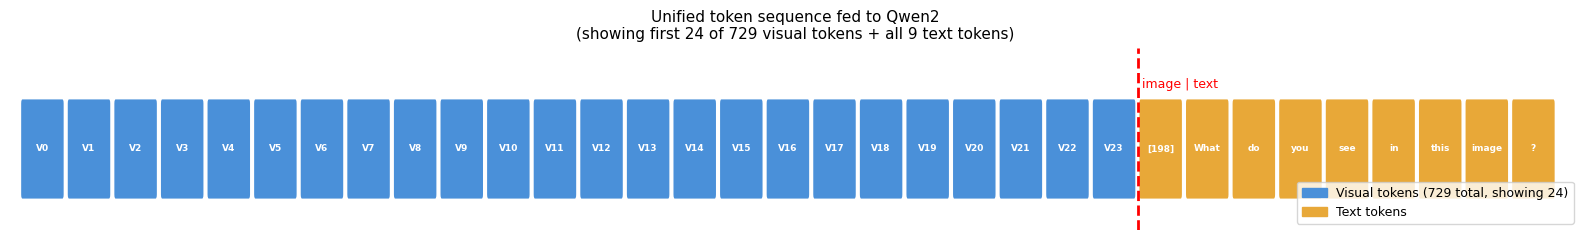

In [88]:
# Reconstruct the token type sequence
# Each <image> placeholder in input_ids maps to exactly ONE visual token
token_ids    = input_ids[0].tolist()
N_visual     = visual_tokens.shape[1]

token_labels = []
token_types  = []

vis_idx = 0
for tid in token_ids:
    if tid == image_token_index:
        # Each placeholder maps 1:1 to a visual token
        token_labels.append(f'V{vis_idx}')
        token_types.append('image')
        vis_idx += 1
    else:
        decoded = processor.tokenizer.decode([tid]).strip() or f'[{tid}]'
        token_labels.append(decoded[:6])
        token_types.append('text')

print(f'Total tokens in merged sequence: {len(token_labels)}')
print(f'  Visual : {token_types.count("image")}')
print(f'  Text   : {token_types.count("text")}')

# Visualise: show first 24 visual + all text tokens
show_vis  = [i for i, t in enumerate(token_types) if t == 'image'][:24]
show_text = [i for i, t in enumerate(token_types) if t == 'text']
show_idx  = sorted(show_vis + show_text)

fig, ax = plt.subplots(figsize=(16, 2.5))
colors = {'image': '#4A90D9', 'text': '#E8A838'}

for plot_pos, idx in enumerate(show_idx):
    ttype = token_types[idx]
    box = mpatches.FancyBboxPatch(
        (plot_pos * 1.15, 0.05), 1.0, 0.9,
        boxstyle='round,pad=0.05',
        facecolor=colors[ttype], edgecolor='white', linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(plot_pos * 1.15 + 0.5, 0.5, token_labels[idx],
            ha='center', va='center', fontsize=6.5,
            color='white', fontweight='bold')

# Separator between image and text regions
last_vis_plot = max(i for i, idx in enumerate(show_idx) if token_types[idx] == 'image')
sep_x = (last_vis_plot + 1) * 1.15 - 0.07
ax.axvline(sep_x, color='red', linewidth=2, linestyle='--')
ax.text(sep_x + 0.1, 1.1, 'image | text', color='red', fontsize=9)

# Create legend handles and pass them to ax.legend()
legend_handles = [
    mpatches.Patch(color='#4A90D9', label=f'Visual tokens ({N_visual} total, showing 24)')
    , mpatches.Patch(color='#E8A838', label='Text tokens')
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)

ax.set_xlim(-0.3, len(show_idx) * 1.15 + 0.5)
ax.set_ylim(-0.3, 1.5)
ax.axis('off')
ax.set_title(
    f'Unified token sequence fed to Qwen2\n'
    f'(showing first 24 of {N_visual} visual tokens + all {token_types.count("text")} text tokens)',
    fontsize=11
)
plt.tight_layout()
plt.show()

**What this shows:** The blue boxes are visual tokens (V0, V1, ...) and the orange boxes are text tokens. The red dashed line marks where the image ends and text begins. Notice that the visual tokens dominate: 729 out of 738 tokens are from the image. This is a characteristic feature of LLaVA — the image takes up most of the context window, which is why SmolVLM's pixel-shuffle compression matters for efficiency.

Now let's look at the attention pattern to understand *how* the text tokens access visual information.

In [ ]:
# Causal attention mask — show a window around the image/text boundary
# The first 729 tokens are image, last 9 are text.
# Showing the first 40 would be all-image — useless. Instead, show the boundary region.

n_img_total  = sum(1 for t in token_types if t == 'image')
n_text_total = sum(1 for t in token_types if t == 'text')

# Take last 20 image tokens + all text tokens
n_img_show  = 20
start       = n_img_total - n_img_show
end         = len(token_types)
types_window = token_types[start:end]
T_show       = len(types_window)

causal = np.tril(np.ones((T_show, T_show)))

# Color the mask by token type: image-to-image, image-to-text, text-to-image, text-to-text
# 0 = masked (no attention), 1 = image attends, 2 = text attends
colored_mask = np.zeros((T_show, T_show))
n_img_in_window = sum(1 for t in types_window if t == 'image')
for q in range(T_show):
    for k in range(T_show):
        if causal[q, k] == 1:
            if q < n_img_in_window:
                colored_mask[q, k] = 1   # image token attending
            else:
                colored_mask[q, k] = 2   # text token attending

from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#f0f0f0', '#4A90D9', '#E8A838'])  # masked, image-attends, text-attends

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(colored_mask, cmap=cmap, vmin=0, vmax=2, aspect='equal')

# Coloured token-type bars on axes
for i, t in enumerate(types_window):
    color = '#4A90D9' if t == 'image' else '#E8A838'
    ax.add_patch(plt.Rectangle((i - 0.5, -1.5), 1, 1, color=color, clip_on=False))
    ax.add_patch(plt.Rectangle((-1.5, i - 0.5), 1, 1, color=color, clip_on=False))

# Mark the visual/text boundary
ax.axhline(n_img_in_window - 0.5, color='red', linewidth=2, linestyle='--')
ax.axvline(n_img_in_window - 0.5, color='red', linewidth=2, linestyle='--')
ax.text(n_img_in_window + 0.5, 1, 'text\nstarts', color='red', fontsize=8)

# Add labels for the quadrants
ax.text(n_img_in_window / 2, n_img_in_window / 2, 'image\nattends to\nimage',
        ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax.text(n_img_in_window / 2, n_img_in_window + n_text_total / 2, 'text attends\nto image',
        ha='center', va='center', fontsize=9, color='black', fontweight='bold')
ax.text(n_img_in_window + n_text_total / 2, n_img_in_window + n_text_total / 2,
        'text\nattends\nto text',
        ha='center', va='center', fontsize=8, color='black', fontweight='bold')

ax.set_xlim(-1.5, T_show - 0.5)
ax.set_ylim(T_show - 0.5, -1.5)
ax.set_xlabel('Key position (can attend TO)', labelpad=15)
ax.set_ylabel('Query position (attending FROM)', labelpad=15)
ax.set_title(
    f'Causal attention mask — last {n_img_show} image + {n_text_total} text tokens\n'
    'Blue = image attending   Orange = text attending   Grey = masked',
    fontsize=10
)
plt.tight_layout()
plt.show()

print('Key observation:')
print(f'  The bottom-left orange block is FULLY filled — every text token attends')
print(f'  to ALL image tokens to its left (all {n_img_total} of them, not just the 20 shown).')
print(f'  No special cross-attention needed — standard causal masking does it all.')

**Reading the plot:** The left columns (blue markers) are the last 20 image tokens; the right columns (orange markers) are the 9 text tokens. The red dashed line marks the boundary.

Three regions to notice:

1. **Blue triangle (upper-left)** — image tokens attending to earlier image tokens. This is a *triangle*, not a full square, because **Qwen2 is a causal decoder**: even image tokens can only attend leftward.

2. **Orange rectangle (bottom-left)** — text tokens attending to image tokens. This block is **completely filled**: every text token can attend to *all* image tokens. This is the key mechanism — no cross-attention needed, just standard causal masking with images placed before text.

3. **Orange triangle (bottom-right)** — text tokens attending to earlier text tokens. Standard causal language modelling.

**A real limitation:** the blue triangle *should* ideally be a full square — image patches are spatial, not sequential, so patch V5 has no reason to be unable to attend to patch V6. Causal masking is the **wrong inductive bias** for image tokens. LLaVA accepts this trade-off for simplicity: by not modifying the LM at all, any off-the-shelf causal decoder can be plugged in. It works in practice because SigLIP already applied 26 layers of **bidirectional** self-attention — so by the time tokens reach Qwen2, each patch vector already encodes global image context.

Other architectures fix this properly:
- **Prefix LM attention** (PaLI, some Gemini variants) — bidirectional for image tokens, causal for text
- **Cross-attention** (Flamingo) — image tokens stay outside the causal sequence entirely; the LM queries them via dedicated cross-attention layers

---
## 10 — Why a Contrastively-Trained Vision Backbone?

A natural question: why use SigLIP (or CLIP) specifically, rather than a ViT trained purely for classification?

The answer lies in how these models were trained. SigLIP learned to align image and text representations using **contrastive learning** on billions of image-text pairs — meaning its embeddings already carry **language-compatible semantic structure**.  
This makes the projector's job much easier: it just needs to rotate and scale a space that is already semantically meaningful, rather than bridging two completely unrelated representations.

Let's make this concrete by measuring image-text similarity using the original CLIP model (a close relative of SigLIP with a publicly accessible text encoder).

Loading weights: 100%|██████████| 590/590 [00:00<00:00, 1907.09it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14-336
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


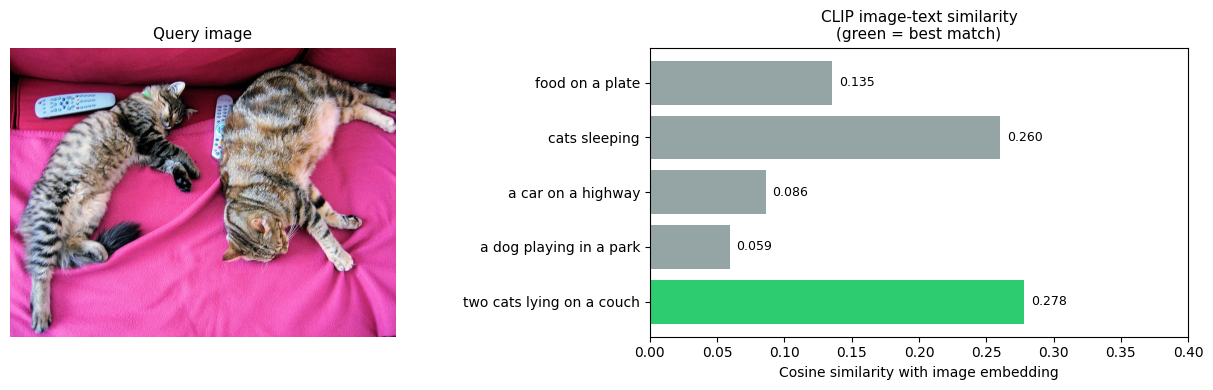

The image embedding is closest to the correct text description.
This alignment is why CLIP features transfer so well to VLMs:
the visual space already speaks a language-compatible dialect.


In [90]:
from transformers import CLIPProcessor, CLIPModel

# Load the standalone CLIP model to access both its vision AND text encoders
clip_model     = CLIPModel.from_pretrained('openai/clip-vit-large-patch14-336').to(device).eval()
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-large-patch14-336')

# Candidate text descriptions
texts = [
    'a photo of two cats lying on a couch',
    'a photo of a dog playing in a park',
    'a photo of a car on a highway',
    'a photo of cats sleeping',
    'a photo of food on a plate',
]

clip_inputs = clip_processor(
    text=texts,
    images=image,
    return_tensors='pt',
    padding=True
).to(device)

with torch.no_grad():
    clip_outputs = clip_model(**clip_inputs)

# Normalised embeddings
img_emb  = clip_outputs.image_embeds / clip_outputs.image_embeds.norm(dim=-1, keepdim=True)
text_emb = clip_outputs.text_embeds  / clip_outputs.text_embeds.norm(dim=-1, keepdim=True)

# Cosine similarity
sims = (img_emb @ text_emb.T).squeeze(0).cpu().numpy()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].imshow(image)
axes[0].set_title('Query image', fontsize=11)
axes[0].axis('off')

colors_bar = ['#2ecc71' if s == sims.max() else '#95a5a6' for s in sims]
short_texts = [t.replace('a photo of ', '') for t in texts]
bars = axes[1].barh(range(len(texts)), sims, color=colors_bar)
axes[1].set_yticks(range(len(texts)))
axes[1].set_yticklabels(short_texts, fontsize=10)
axes[1].set_xlabel('Cosine similarity with image embedding')
axes[1].set_title('CLIP image-text similarity\n(green = best match)', fontsize=11)
axes[1].set_xlim(0, 0.4)
for bar, val in zip(bars, sims):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('The image embedding is closest to the correct text description.')
print('This alignment is why CLIP features transfer so well to VLMs:')
print('the visual space already speaks a language-compatible dialect.')

**This demonstrates the "language-compatible dialect" of CLIP/SigLIP embeddings.** Without any fine-tuning, the vision encoder already knows that this image is about "cats on a couch" — because it was trained to produce embeddings that are geometrically close to the text embeddings of matching descriptions. This pre-existing alignment is what allows LLaVA's tiny 2M-parameter projector to work: it doesn't need to *create* alignment from scratch, it just needs to fine-tune a mapping between two spaces that are already semantically similar.

A classification-trained ViT (e.g., trained only on ImageNet labels) would have no such text alignment — its embedding space would be organised around class boundaries, not linguistic meaning.

---
## Summary — The Full Pipeline with Real Shapes

```
Raw image (PIL, any size)
    │
    ▼  SiglipImageProcessor  (resize + normalise to SigLIP's expected stats)
pixel_values  (1, 3, 384, 384)
    │
    ▼  SigLIP ViT  (vision_tower)  — 398M params
       • splits image into 27×27 = 729 patches  (patch_size=14)
       • runs 26 Transformer layers
       • extracts last hidden layer  (vision_feature_layer = -1)
       • no CLS token — all 729 outputs are patch tokens
hidden_states[-1]  →  (1, 729, 1152)    D_vis = 1152
    │
    ▼  Multi-Modal Projector (MLP)  — ~2M params
       Linear(1152, 1024) → GELU → Linear(1024, 1024)
visual_tokens  (1, 729, 1024)     D_text = 1024
    │
    ├───────────────────────────────────────────────────────┐
    │                                                       │
    │   Raw text: '<image>\nWhat do you see?'               │
    │       │                                               │
    │       ▼  Qwen2Tokenizer                               │
    │   input_ids  (1, 738)  ← 729 <image> + 9 text        │
    │       │                                               │
    │       ▼  embed_tokens table                           │
    │   text_embeds  (1, 738, 1024)                         │
    │                                                       │
    └──────► replace <image> embeds with visual_tokens ◄───┘
                    (1:1 replacement, length unchanged)
                                │
                                ▼
               merged  (1, 738, 1024)
                                │
                                ▼  Qwen2 causal decoder  — 464M params
                           logits  (1, 738, 152000)
                                │
                                ▼  argmax / sampling
                          next token → next token → ...
```

---

### Key takeaways

| Concept | Key insight |
|---|---|
| **SigLIP vision tower** | A ViT trained with contrastive language supervision — its embeddings are already semantically aligned with text |
| **Last hidden layer** | `vision_feature_layer = -1` — this model uses the last layer's output (other LLaVA variants use second-to-last) |
| **No CLS token** | SigLIP has no CLS token (unlike original CLIP). All 729 outputs are spatial patch tokens |
| **Projector** | Just two linear layers + GELU — the entire bridge is ~2M params, mapping D_vis=1152 → D_text=1024 |
| **Token replacement** | The processor expands `<image>` into 729 placeholder tokens; the model replaces their embeddings 1:1 with visual tokens |
| **LM is unchanged** | Qwen2 sees a flat token sequence and applies standard causal attention — no VLM-specific modifications |
| **Causal mask** | Text tokens always attend left → they always see all visual tokens |

---
### LLaVA vs SmolVLM — connector comparison

| | **LLaVA** (this notebook) | **SmolVLM** (previous notebook) |
|---|---|---|
| Vision encoder | SigLIP ViT (1152) | SigLIP ViT (1152) |
| Connector | MLP: 2 linear layers | MLP + pixel shuffle |
| Token reduction | No — all 729 tokens kept | Yes — reduced to ~81 tokens |
| Projector params | ~2M | ~10M |
| LM input length | 729 + text | 81 + text |

The pixel shuffle in SmolVLM is the key efficiency trick: fewer tokens = shorter LM context = faster generation. LLaVA prioritises simplicity over efficiency.

---
### What we didn't cover
- **How the projector is trained**: the vision tower and LM are frozen; only the projector is trained first on image-caption pairs, then the whole model is fine-tuned on instruction data
- **Multi-image & video**: extending the same replacement strategy to multiple `<image>` placeholders
- **Better connectors**: Q-Former (BLIP-2), gated cross-attention (Flamingo) — more parameters, different trade-offs